**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 6**
Extracción de líneas con algoritmo de Canny

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| Luis Fernando Caporal Montes de Oca | A01795898 |  
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A0        |
| Luis Daniel Ortega Muñoz            | A01795197 |
             

# 3. Sobel and Canny Edge Detection

## Table of Contents
1. [Libraries](#libraries)
2. [Sobel Edge Detection](#sobel)
3. [Canny Edge Detection](#canny)
4. [Análisis](análisis)
5. [Referencias](referencias)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import skimage
import numpy as np
from scipy import ndimage
from skimage import exposure
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage.filters import convolve
from scipy.ndimage.filters import gaussian_filter as gauss
from scipy.ndimage.filters import median_filter as med

/tmp/ipykernel_1291/29601034.py:9: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve
/tmp/ipykernel_1291/29601034.py:10: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter as gauss
/tmp/ipykernel_1291/29601034.py:11: DeprecationWarning: Please import `median_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import median_filter as med


## Sobel Edge Detection <a class="anchor" id="sobel" ></a>

As a first step in extracting features, you will apply the Sobel edge detection algorithm. This finds regions of the image with large gradient values in multiple directions. Regions with high omnidirectional gradient are likely to be edges or transitions in the pixel values.

The code in the cell below applies the Sobel algorithm to the median filtered image, using these steps:

1. Convert the color image to grayscale for the gradient calculation since it is two dimensional.
2. Compute the gradient in the x and y (horizontal and vertical) directions.
3. Compute the magnitude of the gradient.
4. Normalize the gradient values.

In [2]:
def edge_sobel(image):
    from scipy import ndimage
    import skimage.color as sc
    import numpy as np
    image = sc.rgb2gray(image) # Convert color image to gray scale
    dx = ndimage.sobel(image, 1)  # horizontal derivative
    dy = ndimage.sobel(image, 0)  # vertical derivative
    mag = np.hypot(dx, dy)  # magnitude
    mag *= 255.0 / np.amax(mag)  # normalize (Q&D)
    mag = mag.astype(np.uint8)
    return mag

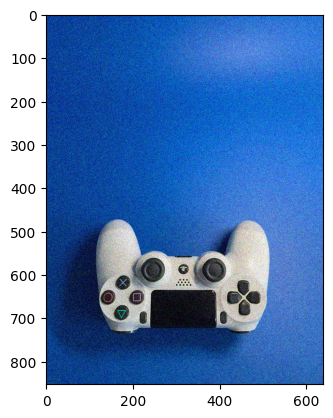

In [3]:
#original_image = np.load('data/img.jpg')
import matplotlib.image as mpimg

original_image = mpimg.imread('data/image_8.jpg')
img = skimage.util.random_noise(original_image)
plt.imshow(img)

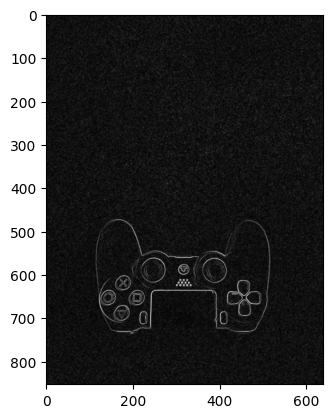

In [4]:
img_med = med(img, size=2)
img_edge = edge_sobel(img_med)
plt.imshow(img_edge, cmap="gray")

Now let's try with the more blurred gaussian filtered image.

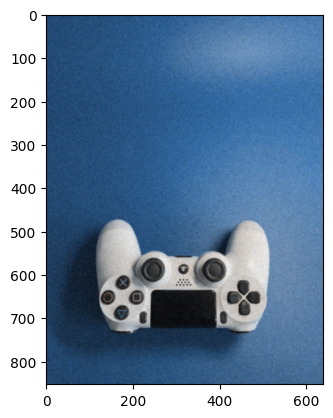

In [5]:
img_gauss = gauss(img, sigma=1)
plt.imshow(img_gauss)

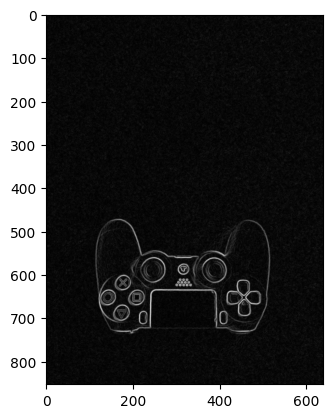

In [6]:
img_edge = edge_sobel(img_gauss)
plt.imshow(img_edge, cmap="gray")

## Canny Edge Detection <a class="anchor" id="canny" ></a>

Steps:
1. Noise Reduction
2. Gradient Calculation
3. Non-maximum Supression
4. Double Threshold
5. Edge Tracking by Hysteresis

**Pre-requisite:** Convert the image to grayscale before algorithm.

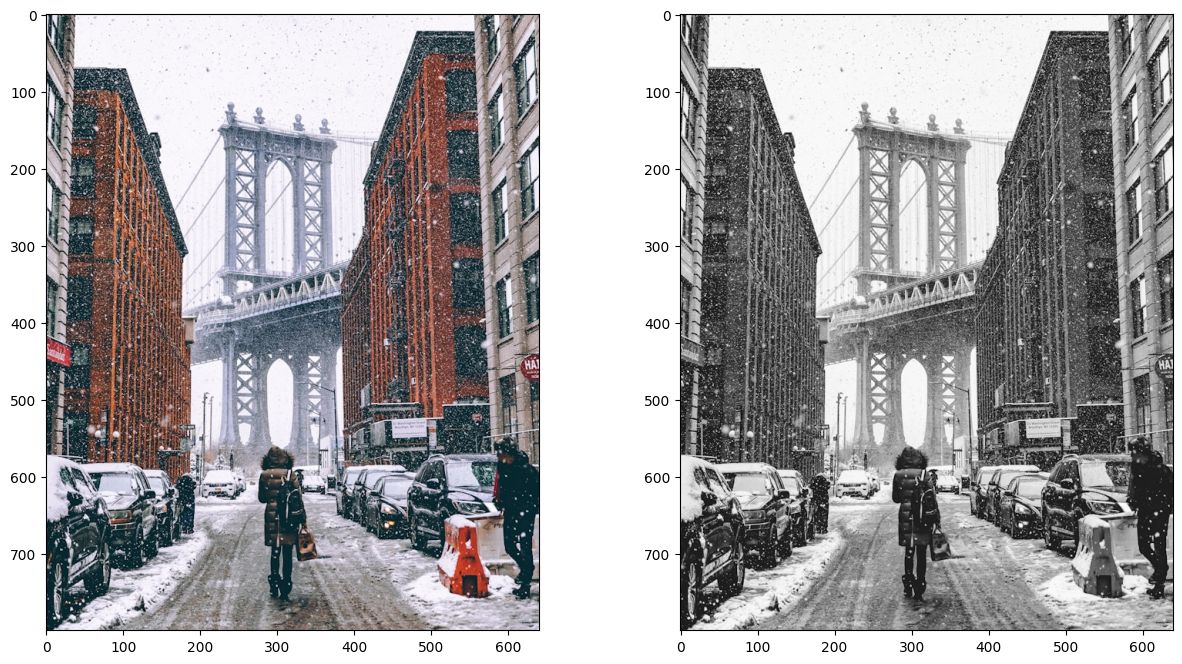

In [7]:
img = cv2.imread('data/image_1.jpg')

img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")

### 1. Noise Reduction
Edge detection are highly sensitive to image noise due to the derivatives behind the algorithm.

We can apply a Gaussian Kernel, the size of the kernel depends on the expected blurring effect. The smaller the less blurring effect.

Equation for Gaussian Kernel of size $(2k+1) \times (2k+1)$

$$
H_{i, j} = \frac{1}{2\pi\sigma^2}exp(-\frac{(i-(k+1))^2 + (j-(k+1))^2}{2\sigma^2}); 1\leq i, j \leq (2k+1)
$$

In [8]:
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

### 1.1 Sigma Parameter $\sigma$

In [9]:
# Change this parameter
sigma = 13 # 1, 3, 5, 10, 20, ...

### 1.2 Kernel Size Parameter

In [10]:
kernel_size = 3

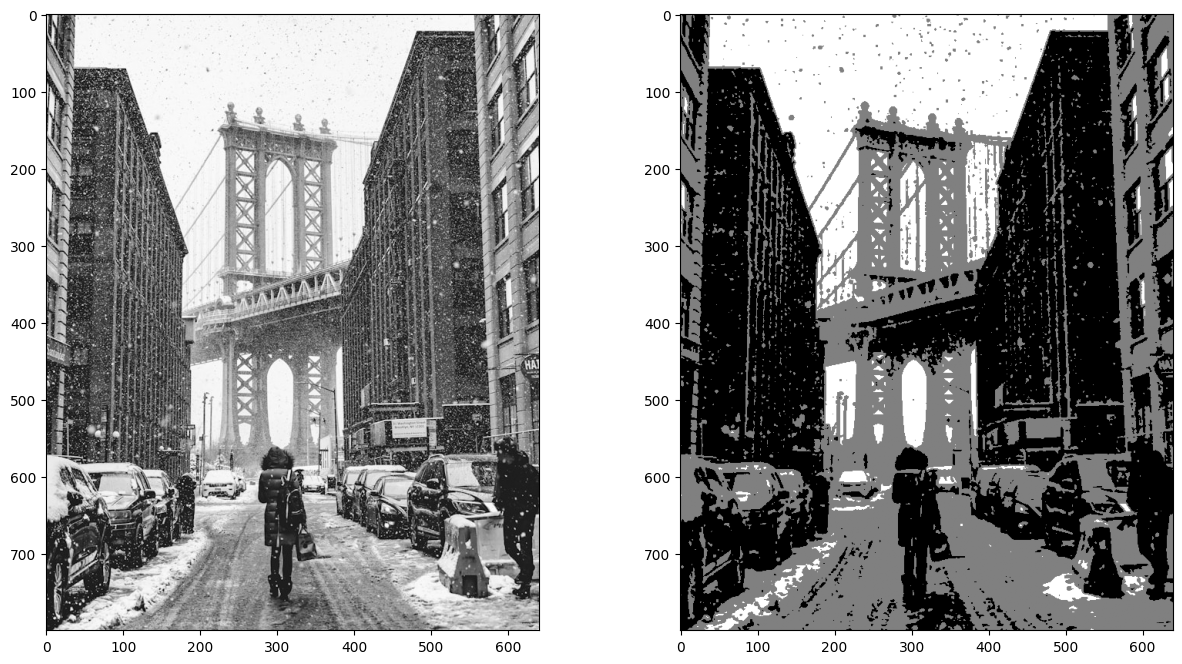

In [11]:
img_gaussian = convolve(img_gray, gaussian_kernel(kernel_size, sigma))

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_gaussian, cmap="gray")

### 2. Gradient Calculation

Edges correspond to a change of pixels intensity.

To detect it, the easiest way is to apply filters that highlight this intensity change in both directions:
- horizontal $(x)$
- and vertical $(y)$

It can be implemented by convoling $I$ with *Sobel kernels* $Kx$ and $Ky$

$$
K_x = \begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix}, K_y = \begin{bmatrix}
1 & 2& 1\\
0 & 0 & 0\\
-1 & -2 & -1
\end{bmatrix}
$$

Then, the magnitude $G$ and the slope $\theta$ of the gradient are calculated as follow:

$$
|G| = \sqrt{I_x^2 + I_y^2},
\theta(x, y) = arctan(\frac{I_y}{I_x})
$$

In [12]:
def sobel_filters(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)

    Ix = ndimage.filters.convolve(img, Kx)
    Iy = ndimage.filters.convolve(img, Ky)

    G = np.hypot(Ix, Iy)
    G = G / G.max() * 255
    theta = np.arctan2(Iy, Ix)

    return (G, theta)

/tmp/ipykernel_1291/3134136643.py:5: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  Ix = ndimage.filters.convolve(img, Kx)
/tmp/ipykernel_1291/3134136643.py:6: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  Iy = ndimage.filters.convolve(img, Ky)


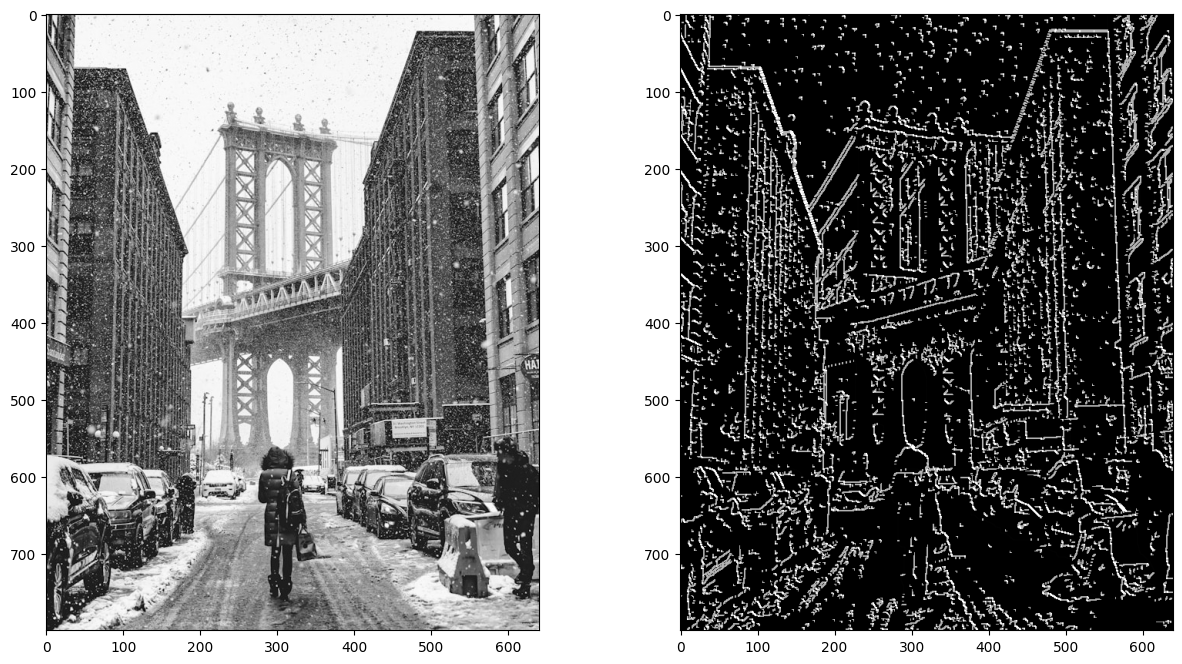

In [13]:
G, theta = sobel_filters(img_gaussian)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(G, cmap="gray")

### 3. Non-Maximum supression

1. Create a matrix initialized to 0 of the same size of the original gradient intensity matrix
2. Identify the edge direction based on the angle value from the angle matrix
3. Check if the pixel in the same direction has a higher intensity than the pixel that is currently processed
4. Return the image processed with the non-max suppression algorithm.

In [14]:
def non_max_suppression(img, D):
    M, N = img.shape
    Z = np.zeros((M,N), dtype=np.int32)
    angle = D * 180. / np.pi
    angle[angle < 0] += 180


    for i in range(1,M-1):
        for j in range(1,N-1):
            try:
                q = 255
                r = 255

               #angle 0
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = img[i, j+1]
                    r = img[i, j-1]
                #angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q = img[i+1, j-1]
                    r = img[i-1, j+1]
                #angle 90
                elif (67.5 <= angle[i,j] < 112.5):
                    q = img[i+1, j]
                    r = img[i-1, j]
                #angle 135
                elif (112.5 <= angle[i,j] < 157.5):
                    q = img[i-1, j-1]
                    r = img[i+1, j+1]

                if (img[i,j] >= q) and (img[i,j] >= r):
                    Z[i,j] = img[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass

    return Z

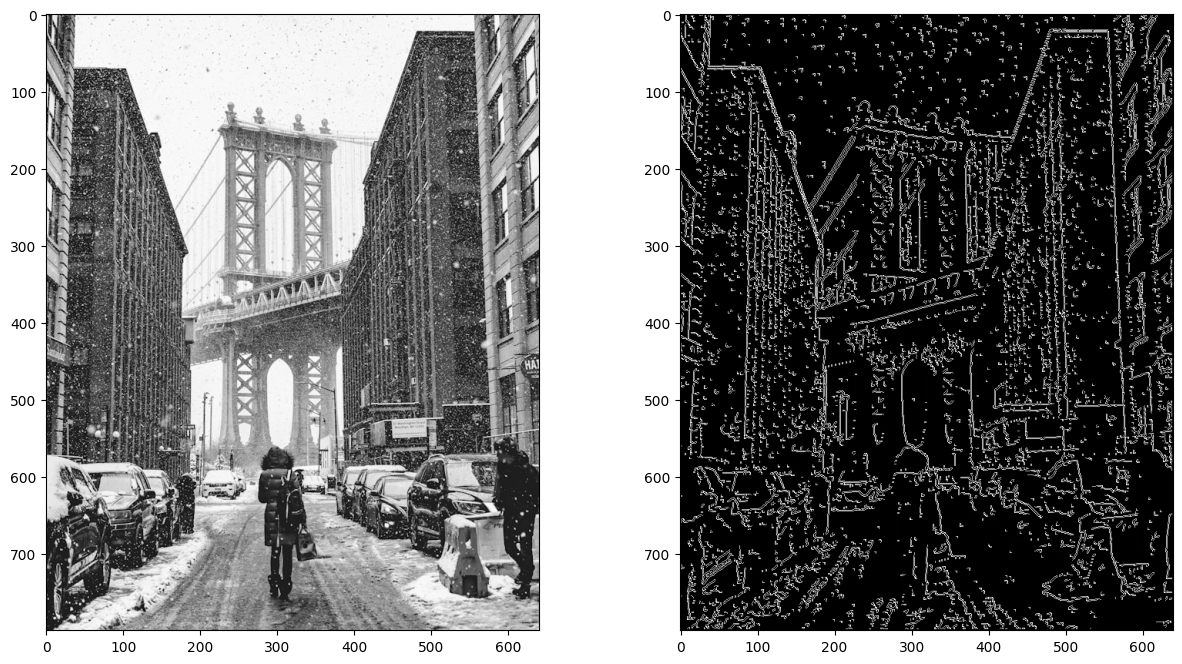

In [15]:
img_nonmax = non_max_suppression(G, theta)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_nonmax, cmap="gray")

### 4. Double threshold

- Strong pixels are pixels that have an intensity so high that we are sure they contribute to the final edge.
- Weak pixels are pixels that have an intensity value that is not enough to be considered as strong ones, but yet not small enough to be considered as non-relevant for the edge detection.
- Other pixels are considered as non-relevant for the edge.

In [16]:
def threshold(img, lowThresholdRatio=0.05, highThresholdRatio=0.09):

    highThreshold = img.max() * highThresholdRatio;
    lowThreshold = highThreshold * lowThresholdRatio;

    M, N = img.shape
    res = np.zeros((M,N), dtype=np.int32)

    weak = np.int32(25)
    strong = np.int32(255)

    strong_i, strong_j = np.where(img >= highThreshold)
    zeros_i, zeros_j = np.where(img < lowThreshold)

    weak_i, weak_j = np.where((img <= highThreshold) & (img >= lowThreshold))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return (res)

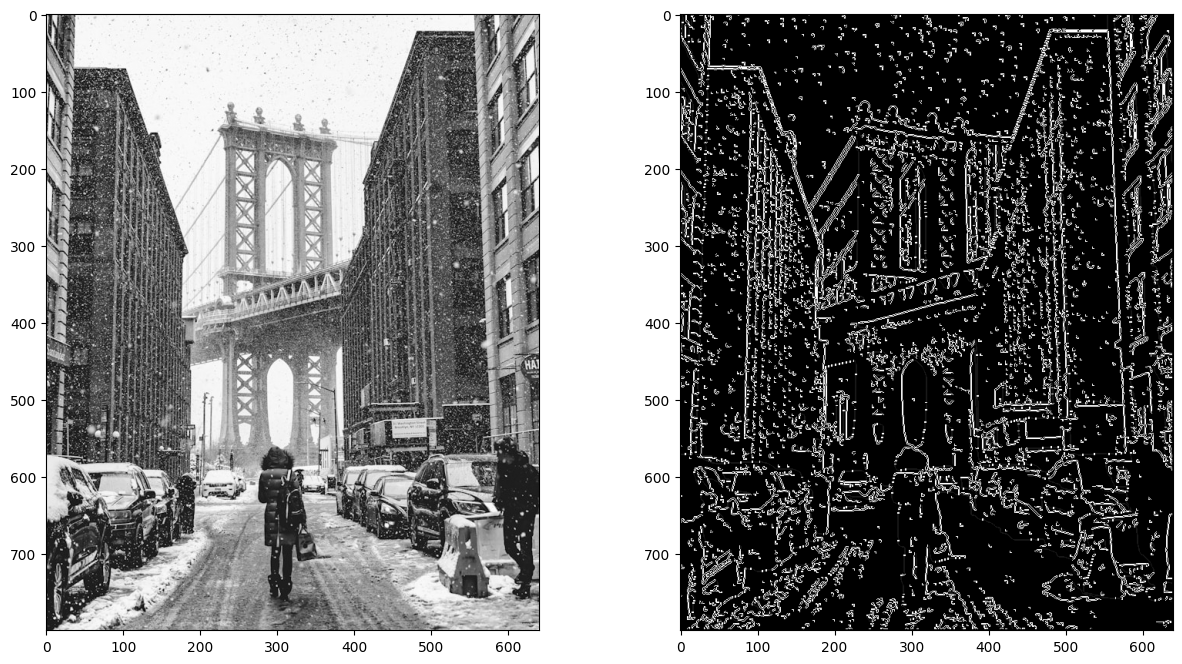

In [17]:
img_threshold = threshold(img_nonmax)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_threshold, cmap="gray")

### 5. Edge Tracking by Hysteresis

The hysteresis consists of transforming weak pixels into strong ones, if and only if at least one of the pixels around the one being processed is a strong one

In [18]:
def hysteresis(img, weak = 75, strong=255):
    M, N = img.shape
    for i in range(1, M-1):
        for j in range(1, N-1):
            if (img[i,j] == weak):
                try:
                    if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or (img[i+1, j+1] == strong)
                        or (img[i, j-1] == strong) or (img[i, j+1] == strong)
                        or (img[i-1, j-1] == strong) or (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                        img[i, j] = strong
                    else:
                        img[i, j] = 0
                except IndexError as e:
                    pass
    return img

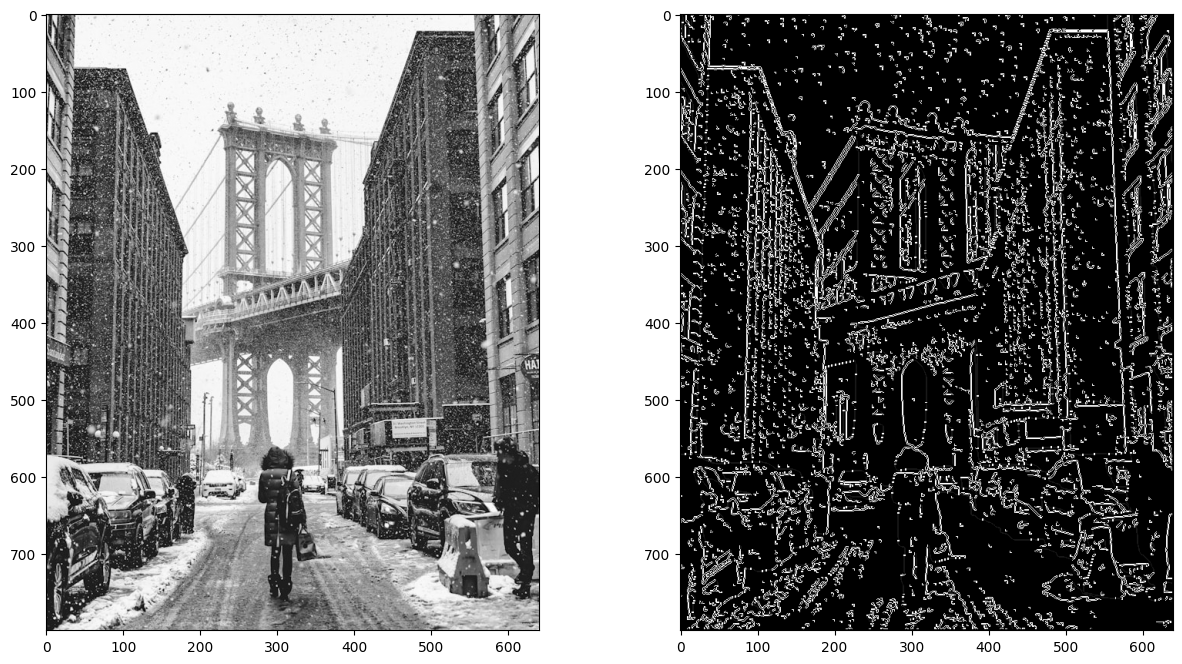

In [19]:
img_final = hysteresis(img_threshold)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_final, cmap="gray")

## Análisis <a class="anchor" id="análisis" ></a>

Los detectores de bordes de Sobel y Canny son dos herramientas fundamentales en el procesamiento de imágenes y la visión por computadora. Ambos algoritmos resaltan contornos y formas dentro de una imagen, pero cada uno posee características y aplicaciones distintas.  

### **Detector de Bordes de Sobel**  

El operador de Sobel es un método sencillo y eficiente para la detección de bordes. Se basa en la aproximación del gradiente de intensidad en direcciones horizontales y verticales.  

#### **Ventajas y Limitaciones**  
- **Sencillez y rapidez:** Fácil de implementar y computacionalmente ligero.  
- **Sensibilidad al ruido:** No incluye un paso de suavizado, por lo que es susceptible a la presencia de ruido.  
- **Detección de bordes básica:** Ideal para aplicaciones donde no se requiere alta precisión.  

#### **Parámetros Ajustables en Sobel**  

1. **Suavizado previo:**  
   - El operador de Sobel no incorpora un suavizado, lo que lo hace sensible al ruido.  
   - **Hallazgo:** Aplicar un filtro Gaussiano o de promediado antes de Sobel reduce el ruido y mejora la claridad de los bordes.  
   - **Observación:** Un suavizado excesivo puede eliminar detalles finos.  

2. **Umbralización del gradiente:**  
   - Una vez calculada la magnitud del gradiente, se puede aplicar un umbral para filtrar bordes.  
   - **Hallazgo:**  
     - Un umbral alto detecta solo los bordes más fuertes.  
     - Un umbral bajo aumenta la sensibilidad, pero puede detectar ruido.  
   - **Observación:** Ajustar el umbral permite equilibrar sensibilidad y especificidad.  

3. **Tamaño del kernel:**  
   - Aunque el operador de Sobel utiliza un kernel estándar de \(3\times3\), se pueden emplear tamaños mayores para detectar estructuras de diferentes escalas.  
   - **Hallazgo:** Kernels más grandes detectan contornos generales, pero pierden detalles finos.  
   - **Observación:** Un kernel más grande aumenta la carga computacional y puede suavizar la imagen en exceso.  

### **Detector de Bordes de Canny**  

El detector de Canny es un algoritmo más sofisticado que ofrece detección de bordes precisa y robusta frente al ruido.  

#### **Ventajas y Limitaciones**  
- **Alta precisión:** Excelente localización de bordes con menor probabilidad de detecciones falsas.  
- **Robustez al ruido:** Utiliza un paso de suavizado inicial que mejora la calidad de la detección.  
- **Mayor complejidad computacional:** Requiere más recursos que el operador de Sobel.  

#### **Parámetros Clave en Canny**  

1. **Sigma del filtro Gaussiano (\(\sigma\))**  
   - Controla el nivel de suavizado previo a la detección de bordes.  
   - **Hallazgo:**  
     - \(\sigma\) pequeño → Menos suavizado, conserva detalles finos pero aumenta la sensibilidad al ruido.  
     - \(\sigma\) grande → Mayor suavizado, reduce ruido y detalles finos, enfocándose en estructuras grandes.  
   - **Observación:** Ajustar \(\sigma\) permite encontrar el balance entre detalle y robustez.  

2. **Umbrales de histéresis (\(T_H\) y \(T_L\))**  
   - Determinan qué bordes son considerados fuertes o débiles.  
   - **Hallazgo:**  
     - Umbrales altos → Detectan solo bordes fuertes.  
     - Umbrales bajos → Aumentan la detección de bordes débiles, pero pueden introducir ruido.  
     - Relación típica: \(T_L = 0.4 \times T_H\).  
   - **Observación:** Ajustar estos valores mejora la continuidad de los bordes y reduce falsas detecciones.  

3. **Tamaño del kernel Gaussiano**  
   - Influye en la cantidad de suavizado aplicado antes de la detección.  
   - **Hallazgo:** Un kernel más grande con \(\sigma\) acorde mejora el suavizado.  
   - **Observación:** Es crucial mantener coherencia entre \(\sigma\) y el tamaño del kernel para evitar efectos no deseados.  

### **Reflexión Final**  

La elección entre Sobel y Canny depende de las necesidades específicas del proyecto. Sobel es una opción rápida y sencilla para detecciones básicas, mientras que Canny ofrece mayor precisión y robustez ante el ruido.  

Ajustar los parámetros de estos detectores permite adaptarlos a distintas condiciones y mejorar su rendimiento. Experimentar con diferentes configuraciones es clave para optimizar la detección de bordes según el tipo de imagen y los objetivos del análisis.


## Referencias <a class="anchor" id="referencias" ></a>

[1] Gonzalez, R. & Woods, R. (2018). Digital Image Processing.  4° Edition. Pearson.

[2] OpenCV: Canny Edge Detection. (s. f.). https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

[3] OpenCV: Canny Edge Detector. (s. f.). https://docs.opencv.org/3.4/da/d5c/tutorial_canny_detector.html

[4] Rosebrock, A. (2023, 8 junio). OpenCV Edge Detection ( Cv2.Canny ) - PyImageSearch. PyImageSearch. https://pyimagesearch.com/2021/05/12/opencv-edge-detection-cv2-canny/
